# Analysis Fine-tuning/Training

In [43]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

HERE = Path(os.getcwd())
PATH_DATA = HERE.parent / '01_aggregated_datasets' / 'training'

In [44]:
from utilities import plot_setup, plot_options_default, save_figure, set_min_ticks

In [45]:
# plotting options
_ = plot_setup(plot_options_default)

## Read Data

In [46]:
# path for data
path_results = PATH_DATA / 'metadata.csv'

# save path
output_directory = HERE / "plots" 
save_flag = 1

In [47]:
df_results = pd.read_csv(path_results)
print(df_results.columns)
df_results

Index(['Unnamed: 0', 'model', 'nodes', 'repeat', 'path_save', 'slurmid'], dtype='object')


,Unnamed: 0,model,nodes,repeat,path_save,slurmid
0,0,llama2_70b_lora,2,0,training/results/000000.parquet,10742795
1,1,llama2_70b_lora,2,1,training/results/000001.parquet,10742796
2,2,llama2_70b_lora,2,2,training/results/000002.parquet,10742797
3,3,llama2_70b_lora,2,3,training/results/000003.parquet,10742798
4,4,llama2_70b_lora,2,4,training/results/000004.parquet,10742800
5,5,llama2_70b_lora,4,0,training/results/000005.parquet,10742829
6,6,llama2_70b_lora,4,1,training/results/000006.parquet,10742831
7,7,llama2_70b_lora,4,2,training/results/000007.parquet,10742832
8,8,llama2_70b_lora,4,3,training/results/000008.parquet,10742833
9,9,llama2_70b_lora,4,4,training/results/000009.parquet,10742834


## Select Model

In [33]:
# select model
label = "llama2_70b_lora"
# label = "stable_diffusion"

In [34]:
title = label.replace('_', ' ').title() + ', '

power_dict = {}
nodes = []
replicates = []

df_results_filtered = df_results[df_results["model"]==label]
list_results = df_results_filtered.to_dict(orient="records")

for irow, row in enumerate(list_results):

    filepath = f"{path_results.parent}/results/{Path(row['path_save']).name}"
    
    # find metadata
    node = row['nodes']
    nodes.append(node)
    replicates.append(row['repeat'])

    # load the parquet file
    df = pd.read_parquet(filepath)

    # assign to dict
    run_id_str = str(irow)
    power_dict[run_id_str] = {}

    power = df['power[W]'].to_list()
    power_dict[run_id_str]['power_kw'] = [x/1e3 for x in power]
    time = df.index.to_list()
    power_dict[run_id_str]['time_s'] = np.asarray([x for x in time])
    power_dict[run_id_str]['nodes'] = node

# Power Profiles Plot

In [35]:
plot_options_default["linewidth"] = 0.5
_ = plot_setup(plot_options_default)

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/02_analysis_scripts/plots/2026-03-20_stable_diffusion_power_profile.png


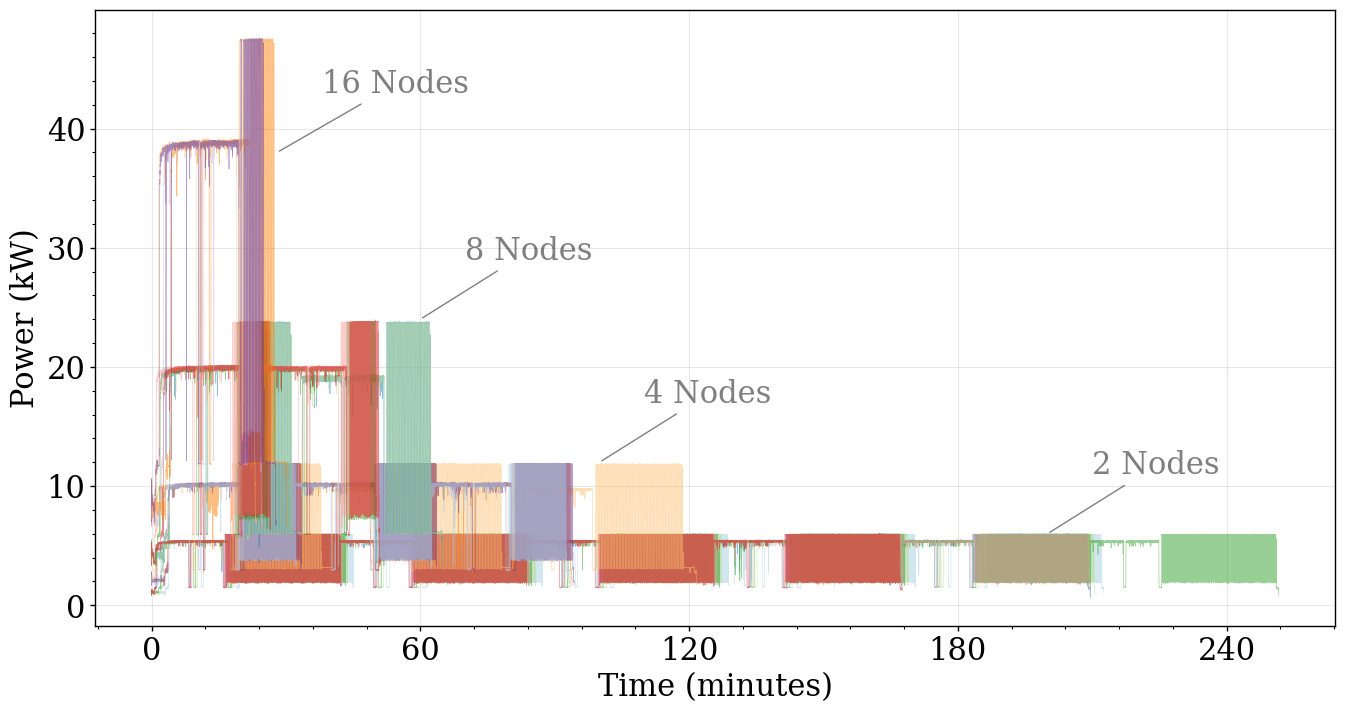

In [36]:
figsize = (16, 8)
fig, ax = plt.subplots(1, 1, figsize=figsize)

def plot_power_profiles(ax):

    for run_id in power_dict.keys():
        run_id_str = str(run_id)

        # plot power profiles
        x = power_dict[run_id_str]['time_s']/60
        y = power_dict[run_id_str]['power_kw']
        ax.plot(x, y, alpha=0.5)

    ax.set(xlabel='Time (minutes)', ylabel='Power (kW)') 
    ax.grid(alpha=0.3)

    if label == 'llama2_70b_lora':
        arrow_xys = [(85, 6), (67, 12), (42, 22), (34, 38)]
        text_xys = [(x[0]+5, x[1]+5) for x in arrow_xys]

    if label == 'stable_diffusion':
        arrow_xys = [(200, 6), (100, 12), (60, 24), (28, 38)]
        text_xys = [(x[0]+10, x[1]+5) for x in arrow_xys]

    for arrow_xy, text_xy, node in zip(arrow_xys, text_xys, [2, 4, 8, 16]):
        ax.annotate(f'{node:n} Nodes',  xy=arrow_xy, xytext=text_xy, alpha=0.5, arrowprops=dict(arrowstyle="-", lw=1, alpha=0.5), fontsize=plot_options_default["fontsize"])
            
    return ax
              
ax = plot_power_profiles(ax)

ax = set_min_ticks(ax, "y", "major", 5)
ax = set_min_ticks(ax, "y", "minor", 5)
ax = set_min_ticks(ax, "x", "minor", 5)
ax = set_min_ticks(ax, "x", "major", 5)

save_figure(
    fig, 
    f'{label}_power_profile', 
    file_format=["png"],  # ["png", "svg", "pdf"]
    full_path=output_directory,
    save_flag=save_flag
)



# Aggregated Plots

In [37]:
plot_options_default["linewidth"] = 3
_ = plot_setup(plot_options_default)

In [38]:
def plot_time_vs_nodes(ax):
        
    # computational time
    t_min = [power_dict[run_id_str]['time_s'][-1]/60 for run_id_str in power_dict]
    ax.plot(
        nodes, 
        t_min, 
        linestyle="none", marker="o", 
        alpha=0.5,
        color=plot_options_default["colors"][0]
    )

    # plot boxplots
    for node in list(set(nodes)):
        points = [x for x, y in zip(t_min, nodes) if y == node]
        ax.boxplot(points, positions=[node], widths=0.5)

    ax.set(xlabel='log(Nodes)', ylabel='log(Time) (minutes)') 
    coefficients = np.polyfit([1/x for x in nodes], t_min, deg=1)
    polynomial_function = np.poly1d(coefficients)
    x_fit = np.linspace(min(nodes), max(nodes), 100) # Generate 100 points between min and max x
    y_fit = polynomial_function(1/x_fit)
    ax.plot(x_fit, y_fit, 'k--', alpha=0.4, label=f'y = {polynomial_function[1]:.2f}/x + {polynomial_function[0]:.2f}')

    # # plot perfect scaling curve
    # t_min_init = [t for n, t in zip(nodes, t_min) if n == 2]
    # t_min_init_avg = np.mean(t_min_init)
    # ax.plot([2, 4, 8, 16], 
    #         [t_min_init_avg, t_min_init_avg/2, t_min_init_avg/4, t_min_init_avg/8], 'k', 
    #         label='perfect scaling') 
    
    # set axes to logarithmic scale                
    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.grid(alpha=0.3)
    ax.legend()

    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))

    # get averages for each node value
    t_min_avg = []
    for nd in [2, 4, 8, 16]:
        t_min_avg.append(round(np.mean([t for n, t in zip(nodes, t_min) if n == nd]), -1))

    xlim = ax.get_xlim()
    ax.set_xlim([xlim[0], 20])
    ax.set_xticks([2, 4, 8, 16])
    if label == 'llama2_70b_lora':
        ax.set_yticks(t_min_avg)
    else:
        ax.set_yticks(t_min_avg)
        
    return ax

# fig, ax = plt.subplots(1, 1, figsize=figsize)
# ax = plot_time_vs_nodes(ax)

In [39]:
def plot_power_avg_vs_nodes(ax):

    # average power
    power_kw_avg = [np.mean(power_dict[run_id_str]['power_kw']) for run_id_str in power_dict]

    ax.plot(
        nodes, 
        power_kw_avg, 
        linestyle="none", marker="o", 
        alpha=0.5,
        color=plot_options_default["colors"][0]
    )

    # plot boxplots
    for node in list(set(nodes)):
        points = [x for x, y in zip(power_kw_avg, nodes) if y == node]
        ax.boxplot(points, positions=[node], widths=0.5)

    ax.set(
        xlabel='Nodes', 
        ylabel='Average Power (kW)'
    )
    ax.grid(alpha=0.3)

    # Fit polynomial
    coefficients = np.polyfit(nodes, power_kw_avg, deg=1)
    polynomial_function = np.poly1d(coefficients)
    x_fit = np.linspace(min(nodes), max(nodes), 100) # Generate 100 points between min and max x
    y_fit = polynomial_function(x_fit)
    ax.plot(x_fit, y_fit, 'k--', alpha=0.4, label=f'y = {polynomial_function[1]:.2f}x + {polynomial_function[0]:.2f}')
    ax.legend()
    
    ax = set_min_ticks(ax, "y", "major", 5)
    ax = set_min_ticks(ax, "y", "minor", 5)
    
    return ax

# fig, ax = plt.subplots(1, 1, figsize=figsize)
# ax = plot_power_avg_vs_nodes(ax)

In [40]:
def plot_power_std_vs_nodes(ax):

    # average power
    power_kw_std = [np.std(power_dict[run_id_str]['power_kw']) for run_id_str in power_dict]

    ax.plot(
        nodes, 
        power_kw_std, 
        linestyle="none", marker="o", 
        alpha=0.5,
        color=plot_options_default["colors"][0]
    )

    # plot boxplots
    for node in list(set(nodes)):
        # filter dict
        points = [x for x, y in zip(power_kw_std, nodes) if y == node]
        ax.boxplot(points, positions=[node], widths=0.5)

    ax.set(
        xlabel='Nodes', 
        ylabel='Power Standard Deviation (kW)' 
    ) 
    ax.yaxis.label.set_size(plot_options_default["fontsize"]*0.8)
    ax.grid(alpha=0.3)

    # Fit polynomial
    coefficients = np.polyfit(nodes, power_kw_std, deg=1)
    polynomial_function = np.poly1d(coefficients)
    x_fit = np.linspace(min(nodes), max(nodes), 100) # Generate 100 points between min and max x
    y_fit = polynomial_function(x_fit)
    ax.plot(x_fit, y_fit, 'k--', alpha=0.4, label=f'y = {polynomial_function[1]:.2f}x + {polynomial_function[0]:.2f}')
    ax.legend()
    
    ax = set_min_ticks(ax, "y", "major", 5)
    ax = set_min_ticks(ax, "y", "minor", 5)
    
    return ax

# fig, ax = plt.subplots(1, 1, figsize=figsize)
# ax = plot_power_std_vs_nodes(ax)

In [41]:

def plot_energy_vs_nodes(ax):

    # energy
    power_kw_avg = [np.mean(power_dict[run_id_str]['power_kw']) for run_id_str in power_dict]
    
    # computational time
    t_min = [power_dict[run_id_str]['time_s'][-1]/60 for run_id_str in power_dict]
    t_h = [t/60 for t in t_min]
    
    print(power_kw_avg)
    print(t_h)

    # energy
    energy_kwh = [x*y for x, y in zip(t_h, power_kw_avg)] 

    ax.plot(
        nodes, 
        energy_kwh, 
        linestyle="none", marker="o", 
        alpha=0.5,
        color=plot_options_default["colors"][0]
    )

    # plot boxplots
    for node in list(set(nodes)):
        points = [x for x, y in zip(energy_kwh, nodes) if y == node]
        ax.boxplot(points, positions=[node], widths=0.5
    )

    ax.set(
        xlabel='Nodes', 
        ylabel='Energy (kWh)',
    )
    ax.grid(alpha=0.3)

    # Fit polynomial
    coefficients = np.polyfit(nodes, energy_kwh, deg=1)
    polynomial_function = np.poly1d(coefficients)
    x_fit = np.linspace(min(nodes), max(nodes), 100) # Generate 100 points between min and max x
    y_fit = polynomial_function(x_fit)
    ax.plot(x_fit, y_fit, 'k--', alpha=0.4, label=f'y = {polynomial_function[1]:.2f}x + {polynomial_function[0]:.2f}')
    ax.legend()
    
    ax = set_min_ticks(ax, "y", "major", 5)
    ax = set_min_ticks(ax, "y", "minor", 5)
    
    return ax

# fig, ax = plt.subplots(1, 1, figsize=figsize)
# ax = plot_energy_vs_nodes(ax)

[np.float64(5.2561640806544325), np.float64(5.344192465963723), np.float64(5.321790483878074), np.float64(5.313479655485304), np.float64(5.315005630359535), np.float64(5.330662269627326), np.float64(8.374240878833247), np.float64(9.879980970492591), np.float64(9.931456903905026), np.float64(9.844962226092564), np.float64(9.90639558785809), np.float64(16.12601467095919), np.float64(16.104064220089537), np.float64(19.005014420059954), np.float64(19.336130575499595), np.float64(18.847133551688593), np.float64(35.75482387275062), np.float64(30.255139130922917), np.float64(34.17405528276504), np.float64(32.131217818778005)]
[np.float64(3.542777777777778), np.float64(3.4941111111111107), np.float64(3.5100555555555557), np.float64(4.194166666666667), np.float64(3.491333333333333), np.float64(2.7927222222222223), np.float64(2.0277777777777777), np.float64(1.5645555555555553), np.float64(1.5575), np.float64(1.5726666666666667), np.float64(1.551611111111111), np.float64(1.0816111111111113), np.f

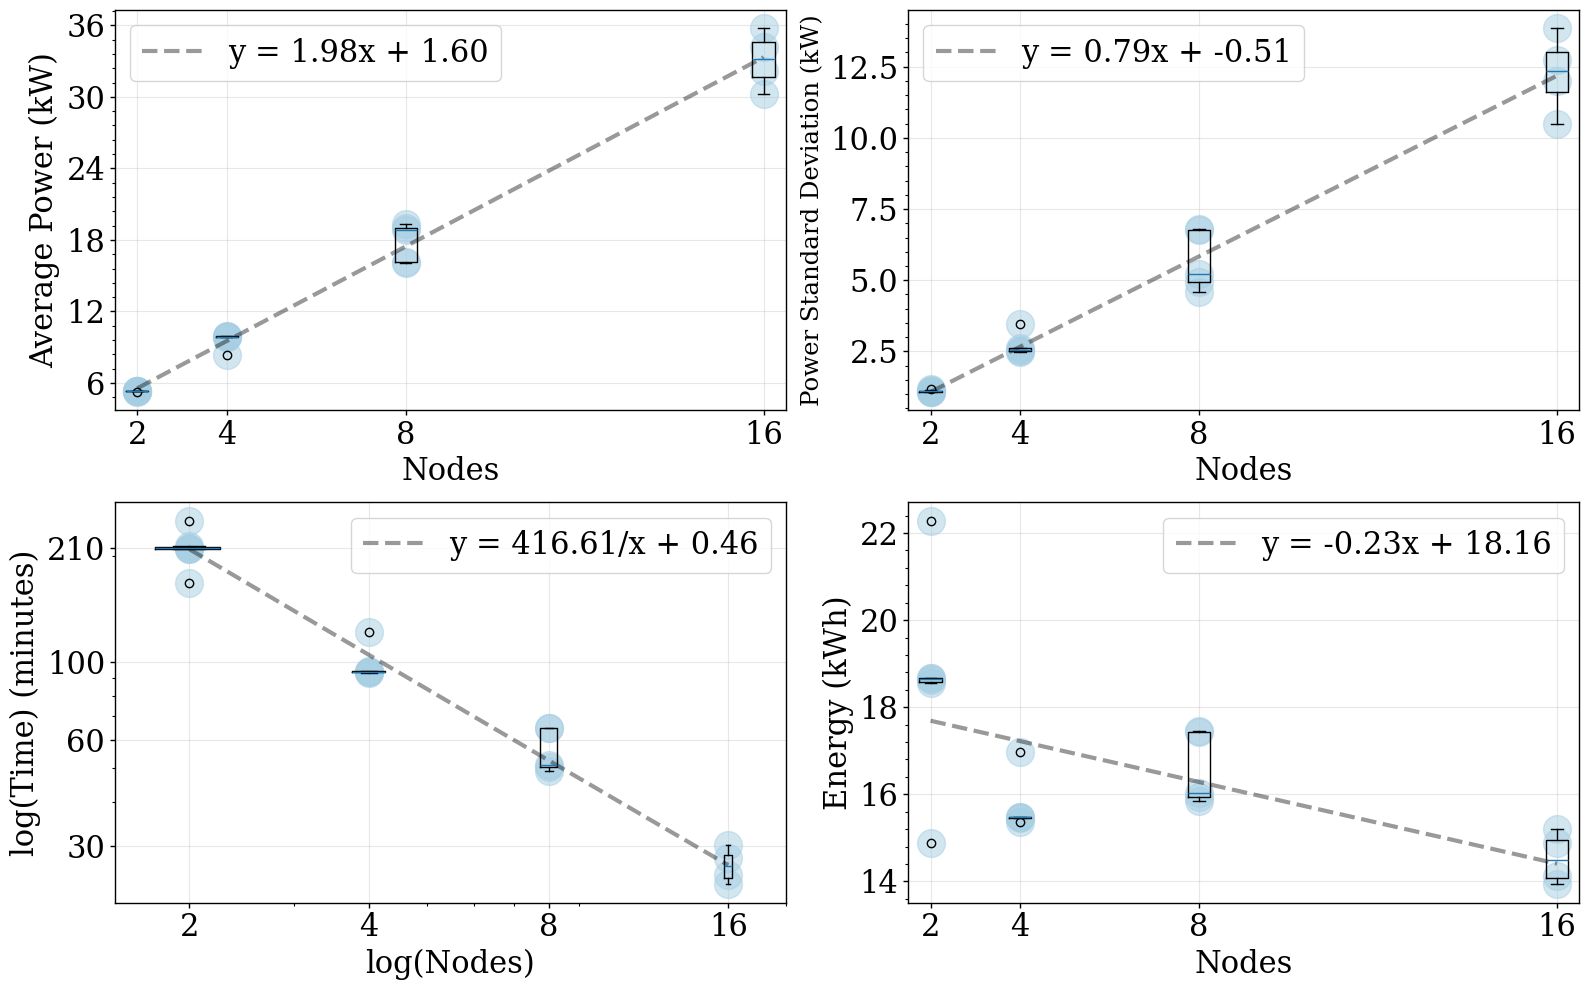

In [42]:
# Create the figure
fig, axes = plt.subplots(2,2, figsize=(16, 10), sharex=False)
ax1, ax2, ax3, ax4 = axes.flatten()

# Plot
ax1 = plot_power_avg_vs_nodes(ax1)
ax2 = plot_power_std_vs_nodes(ax2)
ax3 = plot_time_vs_nodes(ax3)
ax4 = plot_energy_vs_nodes(ax4)

# Adjust layout
plt.tight_layout()

save_figure(
    fig, 
    f'{label}_aggregated', 
    file_format=["png"],
    full_path=output_directory,
    save_flag=save_flag
)